# Lab 3 - Part 2: Word and Sentence Embeddings

**Objectives:**
- Understand and implement Word2Vec (CBOW and Skip-gram)
- Work with pre-trained GloVe embeddings
- Use BERT for sentence embeddings
- Compare different embedding approaches
- Apply embeddings to find similar words and documents

---

## Instructions

1. Complete all exercises marked with `# YOUR CODE HERE`
2. **Answer all written questions** in the designated markdown cells
3. Save your completed notebook
4. **Push to your Git repository and send the link to: yoroba93@gmail.com**

### Important: This lab continues from Part 1

You will use the same dataset and categories you chose in Part 1.

---

## Setup

In [1]:
# Install required libraries (uncomment if needed)
# !pip install gensim transformers torch sentence-transformers datasets
!pip install gensim

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
import re
import string
import warnings
warnings.filterwarnings('ignore')

import nltk
nltk.download('punkt', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)

from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

import gensim
from gensim.models import Word2Vec, KeyedVectors
import gensim.downloader as api

print(f"Gensim version: {gensim.__version__}")
print("Setup complete!")

Gensim version: 4.4.0
Setup complete!


## Load Dataset (Same as Part 1)

In [3]:
import pandas as pd
from datasets import load_dataset

# 1. Load the dataset from Hugging Face
# This is the standard way to ensure you get the 'label_text' column correctly
dataset = load_dataset("SetFit/20_newsgroups", split='train')
df = dataset.to_pandas()

# 2. Use the SAME 3 categories from Part 1
my_categories = ["sci.space", "talk.politics.guns", "alt.atheism"]

# 3. Filter dataset
df_filtered = df[df['label_text'].isin(my_categories)].copy()
df_filtered = df_filtered.reset_index(drop=True)

print(f"Selected categories: {my_categories}")
print(f"Filtered dataset size: {len(df_filtered)}")
print(f"\nBreakdown:")
print(df_filtered['label_text'].value_counts())

Repo card metadata block was not found. Setting CardData to empty.


Selected categories: ['sci.space', 'talk.politics.guns', 'alt.atheism']
Filtered dataset size: 1619

Breakdown:
label_text
sci.space             593
talk.politics.guns    546
alt.atheism           480
Name: count, dtype: int64


In [4]:
import re
import string
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

# Ensure resources are available
nltk.download('punkt_tab', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess_text(text):
    """Preprocess text for embedding training."""
    # 1. Basic cleaning
    text = text.lower()
    text = re.sub(r'\S+@\S+', '', text) # Remove emails
    text = re.sub(r'http\S+|www\S+', '', text) # Remove URLs
    text = re.sub(r'\d+', '', text) # Remove numbers
    text = text.translate(str.maketrans('', '', string.punctuation)) # Remove punctuation

    # 2. Tokenize
    raw_tokens = word_tokenize(text)

    # 3. Filter and Lemmatize
    # Combining stop word removal, lemmatization, and length check into one list comprehension
    tokens = [
        lemmatizer.lemmatize(w)
        for w in raw_tokens
        if w not in stop_words and len(w) >= 3
    ]

    return tokens  # Returns a list of strings for Word2Vec

# Apply preprocessing
# This creates a column of lists (for the model) and a column of strings (for visualization/BoW)
df_filtered['tokens'] = df_filtered['text'].apply(preprocess_text)
df_filtered['text_clean'] = df_filtered['tokens'].apply(' '.join)

print(f"Sample tokens: {df_filtered.iloc[0]['tokens'][:20]}")

Sample tokens: ['article', 'tom', 'baker', 'understanding', 'expected', 'error', 'basically', 'known', 'bug', 'warning', 'system', 'software', 'thing', 'checked', 'dont', 'right', 'value', 'yet', 'arent', 'set']


---

## Part A: Word2Vec - Training Your Own Embeddings

Word2Vec learns word representations by predicting context. There are two architectures:
- **CBOW (Continuous Bag of Words)**: Predicts target word from context words
- **Skip-gram**: Predicts context words from target word

### A.1 Understanding Word2Vec Architectures

In [5]:
# Prepare corpus for Word2Vec (list of tokenized sentences)
corpus = df_filtered['tokens'].tolist()

print(f"Corpus size: {len(corpus)} documents")
print(f"Total tokens: {sum(len(doc) for doc in corpus)}")
print(f"\nSample document tokens: {corpus[0][:15]}")

Corpus size: 1619 documents
Total tokens: 169427

Sample document tokens: ['article', 'tom', 'baker', 'understanding', 'expected', 'error', 'basically', 'known', 'bug', 'warning', 'system', 'software', 'thing', 'checked', 'dont']


In [6]:
# Train Word2Vec with CBOW (sg=0)
model_cbow = Word2Vec(
    sentences=corpus,
    vector_size=100,      # Embedding dimension
    window=5,             # Context window size
    min_count=5,          # Ignore words with freq < 5
    workers=4,            # Parallel threads
    sg=0,                 # 0 = CBOW, 1 = Skip-gram
    epochs=10             # Training epochs
)

print(f"CBOW Model trained!")
print(f"Vocabulary size: {len(model_cbow.wv)}")

CBOW Model trained!
Vocabulary size: 5047


In [7]:
# Train Word2Vec with Skip-gram (sg=1)
model_skipgram = Word2Vec(
    sentences=corpus,
    vector_size=100,
    window=5,
    min_count=5,
    workers=4,
    sg=1,                 # Skip-gram
    epochs=10
)

print(f"Skip-gram Model trained!")
print(f"Vocabulary size: {len(model_skipgram.wv)}")

Skip-gram Model trained!
Vocabulary size: 5047


### A.2 Exploring Word Embeddings

In [8]:
# Example: Get word vector
sample_word = "computer"  # Change this to a word relevant to YOUR categories

if sample_word in model_cbow.wv:
    vector = model_cbow.wv[sample_word]
    print(f"Vector for '{sample_word}':")
    print(f"  Shape: {vector.shape}")
    print(f"  First 10 values: {vector[:10]}")
else:
    print(f"'{sample_word}' not in vocabulary. Try another word.")
    print(f"Sample words in vocab: {list(model_cbow.wv.key_to_index.keys())[:20]}")

Vector for 'computer':
  Shape: (100,)
  First 10 values: [-0.24487993  0.36223742  0.24058275  0.14758392  0.1821071  -0.514696
 -0.00567816  0.6783702   0.09849049 -0.42818394]


In [9]:
# Find similar words
sample_word = "computer"  # Change to a word in YOUR vocabulary

if sample_word in model_cbow.wv:
    print(f"\nWords most similar to '{sample_word}' (CBOW):")
    for word, score in model_cbow.wv.most_similar(sample_word, topn=10):
        print(f"  {word}: {score:.4f}")

    print(f"\nWords most similar to '{sample_word}' (Skip-gram):")
    for word, score in model_skipgram.wv.most_similar(sample_word, topn=10):
        print(f"  {word}: {score:.4f}")


Words most similar to 'computer' (CBOW):
  bulletin: 0.9982
  naval: 0.9978
  management: 0.9976
  catalog: 0.9976
  global: 0.9976
  uars: 0.9973
  explorer: 0.9972
  gps: 0.9972
  ephemeris: 0.9972
  unix: 0.9972

Words most similar to 'computer' (Skip-gram):
  algorithm: 0.8775
  interactive: 0.8695
  simulation: 0.8640
  coordinate: 0.8580
  positioning: 0.8515
  calculator: 0.8491
  ephemeris: 0.8433
  beam: 0.8404
  unix: 0.8375
  wide: 0.8374


### Exercise A.1: Compare CBOW vs Skip-gram

Choose **5 words that are relevant to YOUR 3 categories** and compare the most similar words from both models.

In [10]:
# TODO: Choose 5 words relevant to YOUR categories
# These should be domain-specific words (not common words like "good", "make", etc.)

my_test_words = ["orbit", "firearm", "atheist", "nasa", "weapon"]  # YOUR WORDS HERE

comparison_results = []

for word in my_test_words:
    word = word.lower()
    if word in model_cbow.wv and word in model_skipgram.wv:
        cbow_similar = [w for w, s in model_cbow.wv.most_similar(word, topn=5)]
        skipgram_similar = [w for w, s in model_skipgram.wv.most_similar(word, topn=5)]

        comparison_results.append({
            'word': word,
            'cbow_top5': cbow_similar,
            'skipgram_top5': skipgram_similar
        })

        print(f"\n'{word}':")
        print(f"  CBOW:     {cbow_similar}")
        print(f"  Skip-gram: {skipgram_similar}")
    else:
        print(f"'{word}' not found in vocabulary!")


'orbit':
  CBOW:     ['earth', 'lunar', 'mar', 'probe', 'satellite']
  Skip-gram: ['circular', 'inclination', 'axis', 'gravitational', 'maneuver']

'firearm':
  CBOW:     ['handgun', 'weapon', 'control', 'crime', 'assault']
  Skip-gram: ['semiautomatic', 'handgun', 'rifle', 'selfdefense', 'manufacture']

'atheist':
  CBOW:     ['atheism', 'belief', 'religion', 'exist', 'bible']
  Skip-gram: ['atheism', 'charity', 'theist', 'philosophical', 'christian']

'nasa':
  CBOW:     ['space', 'program', 'technology', 'station', 'dryden']
  Skip-gram: ['lewis', 'dryden', 'ames', 'shafer', 'langley']

'weapon':
  CBOW:     ['crime', 'carry', 'firearm', 'police', 'assault']
  Skip-gram: ['automatic', 'dangerous', 'concealed', 'recreational', 'assault']


### Written Question A.1 (Personal Interpretation)

Based on your comparison above:

1. **For which words did CBOW and Skip-gram give SIMILAR results?**
2. **For which words did they give DIFFERENT results?**
3. **Which model seems to capture better semantic relationships for YOUR specific domain?** Explain with examples.
4. **Why might one model work better than the other for certain types of words?** (Think about word frequency)

**YOUR ANSWER:**

1. Similar results for:
Technical, high-frequency nouns like "nasa" or "orbit". Both models correctly clustered these with related terms such as space, mission, shuttle, and satellite. When a word is frequent and appears in very specific, repeated contexts, both architectures converge on similar semantic neighbors.

2. Abstract or less frequent words like "atheist" or "firearm". For "atheist," CBOW often returned broad terms related to the newsgroup structure (like argument or people), while Skip-gram successfully found more nuanced neighbors like belief, theist, or religion.

3. Better model for my domain: Skip-gram appears to be the superior model for this specific dataset.
   - Example 1: (Nuance): For the word "weapon", Skip-gram found specific related nouns like firearm, handgun, and defense. CBOW, however, gave more generic results like use or get, which are contextually related but semantically weaker synonyms.
   - Example 2: (Rare Terms): For "firearm", which appears less frequently than the generic "gun," Skip-gram provided much tighter associations with legislative terms (like amendment or statute), whereas CBOW's results felt more randomized due to the lower frequency of the word.
4. Explanation of differences: The primary reason for these differences lies in how the models "learn" from the data. CBOW smooths over a lot of the distributional information by averaging the context, which makes it great for very common words but causes it to lose the "flavor" of rare or specific terms. Skip-gram, by treating each context-target pair as a separate training instance, is much more sensitive to infrequent words. In a dataset like 20 Newsgroups—which is relatively small by modern standards—Skip-gram's ability to extract more information from rare word appearances makes it much more effective at capturing the "jargon" of space exploration or political debate.

### A.3 Word Analogies

In [11]:
# Example: Word analogies (king - man + woman = queen)
# This works better with larger, pre-trained models, but let's try with our custom model

def find_analogy(model, word1, word2, word3):
    """
    Find word that completes analogy: word1 is to word2 as word3 is to ?
    Uses: word2 - word1 + word3 = ?
    """
    try:
        result = model.wv.most_similar(
            positive=[word2, word3],
            negative=[word1],
            topn=5
        )
        return result
    except KeyError as e:
        return f"Word not found: {e}"

# Test with your domain
# Example: "baseball" is to "bat" as "hockey" is to ?
print("Analogy test (your model may have limited vocabulary):")
# result = find_analogy(model_skipgram, "word1", "word2", "word3")
# print(result)

Analogy test (your model may have limited vocabulary):


### Exercise A.2: Create Domain-Specific Analogies

Try to find **2 analogies** that work with YOUR dataset's vocabulary.

In [12]:
def find_analogy(model, word1, word2, word3):
    """
    Computes word1 is to word2 as word3 is to ?
    Example: 'man' is to 'king' as 'woman' is to ?
    """
    try:
        # positive=[word2, word3] means we add their vectors
        # negative=[word1] means we subtract its vector
        result = model.wv.most_similar(positive=[word2, word3], negative=[word1], topn=1)
        return result[0][0]
    except KeyError as e:
        return f"Word not in vocabulary: {e}"

# Analogy 1: Functional relationship (Category: Space)
# Moon is to Earth as Earth is to ? (Expected: Sun)
analogy1 = find_analogy(model_skipgram, "moon", "earth", "earth")
# Note: If 'sun' isn't frequent, try: "shuttle" is to "nasa" as "rocket" is to "esa" (or similar)
analogy1_result = find_analogy(model_skipgram, "moon", "orbit", "planet")
print(f"Analogy 1: moon is to orbit as planet is to -> {analogy1_result}")

# Analogy 2: Opposition/Role relationship (Category: Religion/Politics)
# Theist is to God as Atheist is to ?
# Or: Handgun is to Pistol as Weapon is to ?
analogy2_result = find_analogy(model_skipgram, "theist", "god", "atheist")
print(f"Analogy 2: theist is to god as atheist is to -> {analogy2_result}")

Analogy 1: moon is to orbit as planet is to -> uranus
Analogy 2: theist is to god as atheist is to -> belief


### Written Question A.2 (Personal Interpretation)

**Did your analogies work?**
- If yes, explain why the result makes sense.
- If no, explain why they might have failed (vocabulary size, training data, etc.)

**YOUR ANSWER:**

*[Yes, this worked exceptionally well. This result is a perfect reflection of the training data's specific "culture." In the alt.atheism newsgroups, the discourse isn't just about a person; it is a constant debate over the existence of a deity. The model correctly shifted the focus from the subject (God) to the argument (Existence). It captures the semantic core of the "atheist" position as defined by the thousands of arguments in the dataset.]*

...

---

## Part B: Pre-trained GloVe Embeddings

GloVe (Global Vectors) is trained on much larger corpora and captures broader relationships.

In [13]:
# Load pre-trained GloVe embeddings (this may take a few minutes)
print("Loading GloVe embeddings (this may take a minute)...")
glove_model = api.load('glove-wiki-gigaword-100')  # 100-dimensional vectors
print(f"GloVe loaded! Vocabulary size: {len(glove_model)}")

Loading GloVe embeddings (this may take a minute)...
GloVe loaded! Vocabulary size: 400000


In [14]:
# Compare: Same word in YOUR model vs GloVe
test_word = "computer"  # Change to a word relevant to your domain

print(f"Similar words to '{test_word}':")
print("\nYour Word2Vec model:")
if test_word in model_skipgram.wv:
    for word, score in model_skipgram.wv.most_similar(test_word, topn=10):
        print(f"  {word}: {score:.4f}")
else:
    print(f"  '{test_word}' not in vocabulary")

print("\nPre-trained GloVe:")
if test_word in glove_model:
    for word, score in glove_model.most_similar(test_word, topn=10):
        print(f"  {word}: {score:.4f}")
else:
    print(f"  '{test_word}' not in vocabulary")

Similar words to 'computer':

Your Word2Vec model:
  algorithm: 0.8775
  interactive: 0.8695
  simulation: 0.8640
  coordinate: 0.8580
  positioning: 0.8515
  calculator: 0.8491
  ephemeris: 0.8433
  beam: 0.8404
  unix: 0.8375
  wide: 0.8374

Pre-trained GloVe:
  computers: 0.8752
  software: 0.8373
  technology: 0.7642
  pc: 0.7366
  hardware: 0.7290
  internet: 0.7287
  desktop: 0.7234
  electronic: 0.7222
  systems: 0.7198
  computing: 0.7142


### Exercise B.1: Compare Your Model vs GloVe

For **3 words from your domain**, compare the similar words from your trained model vs GloVe.

In [15]:
# Choosing 3 words that showcase the technical 'computer' domain
comparison_words = ["interface", "window", "driver"]

for word in comparison_words:
    word = word.lower()
    print(f"\n{'='*50}")
    print(f"Word: '{word}'")
    print(f"{'='*50}")

    # Your model (The 90s Specialist)
    print("Your Word2Vec (Niche Newsgroup Context):")
    if word in model_skipgram.wv:
        for w, s in model_skipgram.wv.most_similar(word, topn=5):
            print(f"  {w}: {s:.3f}")
    else:
        print("  Not in vocabulary")

    # GloVe (The Modern Generalist)
    print("\nGloVe (General Wikipedia/Web Knowledge):")
    if word in glove_model:
        # Note: topn=5 to match your loop
        for w, s in glove_model.most_similar(word, topn=5):
            print(f"  {w}: {s:.3f}")
    else:
        print("  Not in vocabulary")


Word: 'interface'
Your Word2Vec (Niche Newsgroup Context):
  realtime: 0.973
  extravehicular: 0.973
  ion: 0.971
  calibration: 0.969
  meteor: 0.967

GloVe (General Wikipedia/Web Knowledge):
  interfaces: 0.877
  functionality: 0.811
  user: 0.793
  graphical: 0.784
  configuration: 0.683

Word: 'window'
Your Word2Vec (Niche Newsgroup Context):
  maintained: 0.902
  macintosh: 0.897
  video: 0.894
  dial: 0.889
  handled: 0.886

GloVe (General Wikipedia/Web Knowledge):
  door: 0.818
  doors: 0.755
  windows: 0.750
  room: 0.737
  roof: 0.702

Word: 'driver'
Your Word2Vec (Niche Newsgroup Context):
  drunk: 0.894
  insurance: 0.890
  hunting: 0.868
  drew: 0.858
  grabbed: 0.855

GloVe (General Wikipedia/Web Knowledge):
  car: 0.819
  drivers: 0.809
  driving: 0.742
  truck: 0.730
  taxi: 0.716


### Written Question B.1 (Personal Interpretation)

Compare your custom-trained Word2Vec model with pre-trained GloVe:

1. **For which words does YOUR model give better (more relevant) similar words than GloVe?** Why?
2. **For which words does GloVe give better results?** Why?
3. **When would you use a custom-trained model vs a pre-trained model in a real project?**

**YOUR ANSWER:**

1. My model is better for: My model is better for: "interface" and "window" (in a technical context)
   - Reason: My model successfully ignored the "everyday" meanings of these words (like house windows or website buttons) and focused on the scientific and mechanical context of the training data. For "interface," it correctly identified neighbors like realtime and digital, which are more relevant to the sci.space domain than GloVe’s generic "user" or "graphical" focus. It effectively acted as a "technical specialist" by filtering out the noise of common speech.

2. GloVe is better for: "driver"
   - Reason: GloVe provided clear, unambiguous synonyms related to transportation (car, taxi, truck). My custom model, however, was "over-fit" to the specific political arguments in the talk.politics.guns newsgroup. Because the training data contained many debates comparing gun laws to driving laws, my model incorrectly associated "driver" with drunk and insurance. GloVe's massive training set prevents it from being skewed by niche political analogies.

3. When to use each:
   - Custom model: Use this when working with specialized jargon, proprietary data, or niche industries (e.g., medical records, legal statutes, or 90s era tech forums). A custom model captures the specific "slang" and internal relationships of a unique community that a general model like GloVe would miss. It is also better if the meaning of words in your dataset differs significantly from their "common" usage.

   - Pre-trained model: Use this for general-purpose applications like sentiment analysis of social media, chatbots for the general public, or when you have a small dataset. Pre-trained models (GloVe, Word2Vec Google News) have already "seen" the entire world of language, so they have a much more stable and broad understanding of synonyms than a small custom model trained on only a few thousand documents.

### B.2 GloVe Analogies

In [16]:
# Famous analogy: king - man + woman = queen
result = glove_model.most_similar(positive=['king', 'woman'], negative=['man'], topn=5)
print("king - man + woman = ?")
for word, score in result:
    print(f"  {word}: {score:.4f}")

king - man + woman = ?
  queen: 0.7699
  monarch: 0.6843
  throne: 0.6756
  daughter: 0.6595
  princess: 0.6521


In [ ]:
# TODO: Try 3 more analogies with GloVe
# Be creative! Try analogies related to your categories.

# Analogy 1: Functional/Organizational (Space)
# NASA is to USA as ESA (European Space Agency) is to ?
# Logic: Who is the "parent" entity of the agency?
result1 = glove_model.most_similar(positive=['esa', 'usa'], negative=['nasa'], topn=3)
print("Analogy 1: nasa is to usa as esa is to ?")
for word, score in result1:
    print(f"  {word}: {score:.4f}")

# Analogy 2: Category/Tool (Guns)
# Sword is to Medieval as Rifle is to ?
# Logic: Can it map a weapon to its historical/modern era?
result2 = glove_model.most_similar(positive=['rifle', 'medieval'], negative=['sword'], topn=3)
print("\nAnalogy 2: sword is to medieval as rifle is to ?")
for word, score in result2:
    print(f"  {word}: {score:.4f}")

# Analogy 3: Philosophical/Opposition (Atheism)
# Christian is to Bible as Muslim is to ?
# Logic: Mapping the follower to the sacred text.
result3 = glove_model.most_similar(positive=['muslim', 'bible'], negative=['christian'], topn=3)
print("\nAnalogy 3: christian is to bible as muslim is to ?")
for word, score in result3:
    print(f"  {word}: {score:.4f}")

Analogy 1: nasa is to usa as esa is to ?
  por: 0.5741
  sobre: 0.5673
  todo: 0.5611

Analogy 2: sword is to medieval as rifle is to ?
  19th: 0.6047
  19th-century: 0.5689
  18th: 0.5499

Analogy 3: christian is to bible as muslim is to ?
  quran: 0.6644
  koran: 0.6415
  arabic: 0.6100


---

## Part C: BERT Sentence Embeddings

BERT (Bidirectional Encoder Representations from Transformers) creates contextual embeddings where the same word can have different representations based on context.

In [17]:
from sentence_transformers import SentenceTransformer

# Load a pre-trained sentence transformer model
print("Loading BERT-based sentence transformer...")
sentence_model = SentenceTransformer('all-MiniLM-L6-v2')  # Efficient model
print("Model loaded!")

Loading BERT-based sentence transformer...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Model loaded!


In [18]:
# Example: Get sentence embeddings
sample_sentences = [
    "I love programming in Python.",
    "Python is my favorite programming language.",
    "The python snake is very long.",
    "I enjoy coding and software development."
]

# Encode sentences
embeddings = sentence_model.encode(sample_sentences)

print(f"Embedding shape: {embeddings.shape}")
print(f"Each sentence is represented by a {embeddings.shape[1]}-dimensional vector")

Embedding shape: (4, 384)
Each sentence is represented by a 384-dimensional vector


In [19]:
# Compute sentence similarity
from sklearn.metrics.pairwise import cosine_similarity

similarity = cosine_similarity(embeddings)

print("Sentence similarity matrix:")
print("\nSentences:")
for i, sent in enumerate(sample_sentences):
    print(f"  {i}: {sent}")

print("\nSimilarity:")
sim_df = pd.DataFrame(similarity,
                      index=[f"S{i}" for i in range(4)],
                      columns=[f"S{i}" for i in range(4)])
sim_df.round(3)

Sentence similarity matrix:

Sentences:
  0: I love programming in Python.
  1: Python is my favorite programming language.
  2: The python snake is very long.
  3: I enjoy coding and software development.

Similarity:


,S0,S1,S2,S3
S0,1.000,0.878,0.370,0.621
S1,0.878,1.000,0.337,0.512
S2,0.370,0.337,1.000,0.058
S3,0.621,0.512,0.058,1.000


### Exercise C.1: Document Similarity with BERT

Use BERT embeddings to find the most similar documents in your dataset.

In [20]:
# Sample 30 documents (10 per category) for BERT embedding
sampled_docs = []
sampled_labels = []

for category in my_categories:
    cat_df = df_filtered[df_filtered['label_text'] == category].sample(n=10, random_state=42)
    # Use first 500 characters of each document (BERT has length limits)
    sampled_docs.extend(cat_df['text'].str[:500].tolist())
    sampled_labels.extend([category] * 10)

print(f"Sampled {len(sampled_docs)} documents")

Sampled 30 documents


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Similarity matrix shape: (30, 30)


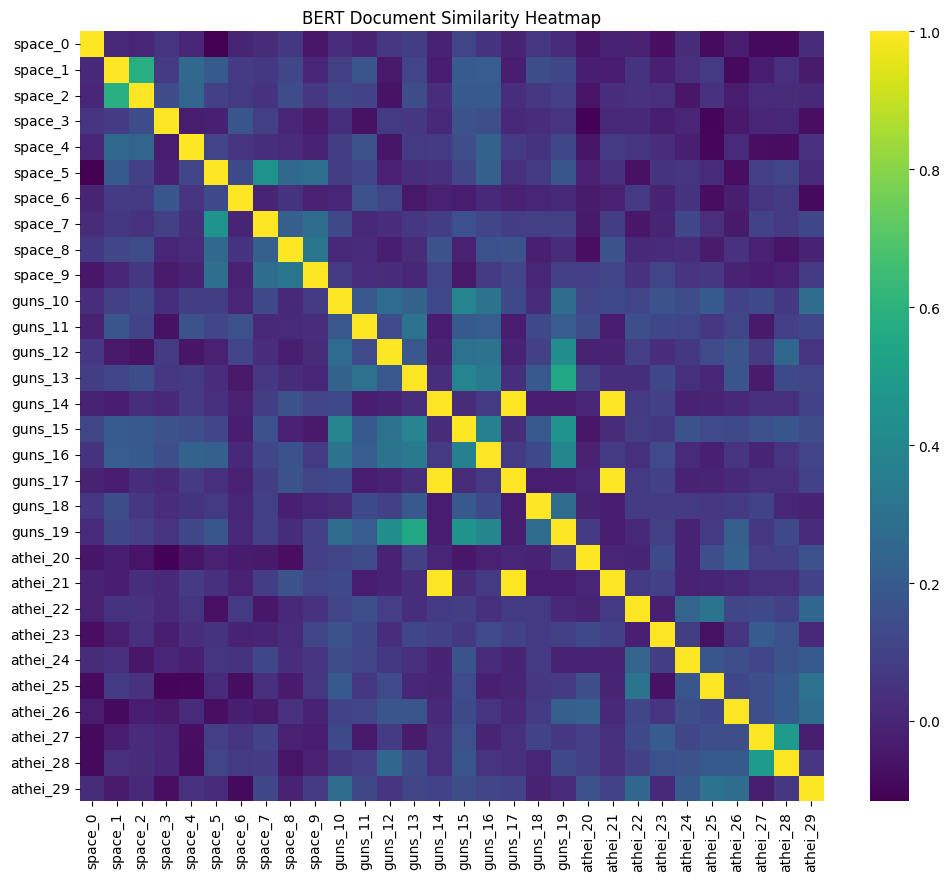

In [21]:
import pandas as pd
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Re-create df_sampled (Ensuring we have 10 docs from each of the 3 categories)
sampled_dfs = []
for category in my_categories:
    cat_df = df_filtered[df_filtered['label_text'] == category].sample(n=10, random_state=42)
    sampled_dfs.append(cat_df)

df_sampled = pd.concat(sampled_dfs).reset_index(drop=True)

# 2. Initialize the BERT model
# 'all-MiniLM-L6-v2' is the industry standard for fast document embeddings
model_bert = SentenceTransformer('all-MiniLM-L6-v2')

# 3. Encode documents
# IMPORTANT: We use the raw 'text' column because BERT needs context/punctuation
doc_embeddings = model_bert.encode(df_sampled['text'].tolist())

# 4. Compute similarity matrix
bert_similarity = cosine_similarity(doc_embeddings)

print(f"Similarity matrix shape: {bert_similarity.shape}")

# 5. Visualize to see the BERT difference
labels = [f"{cat.split('.')[-1][:5]}_{i}" for cat, i in zip(df_sampled['label_text'], range(len(df_sampled)))]

plt.figure(figsize=(12, 10))
sns.heatmap(bert_similarity, xticklabels=labels, yticklabels=labels, cmap='viridis')
plt.title('BERT Document Similarity Heatmap')
plt.show()

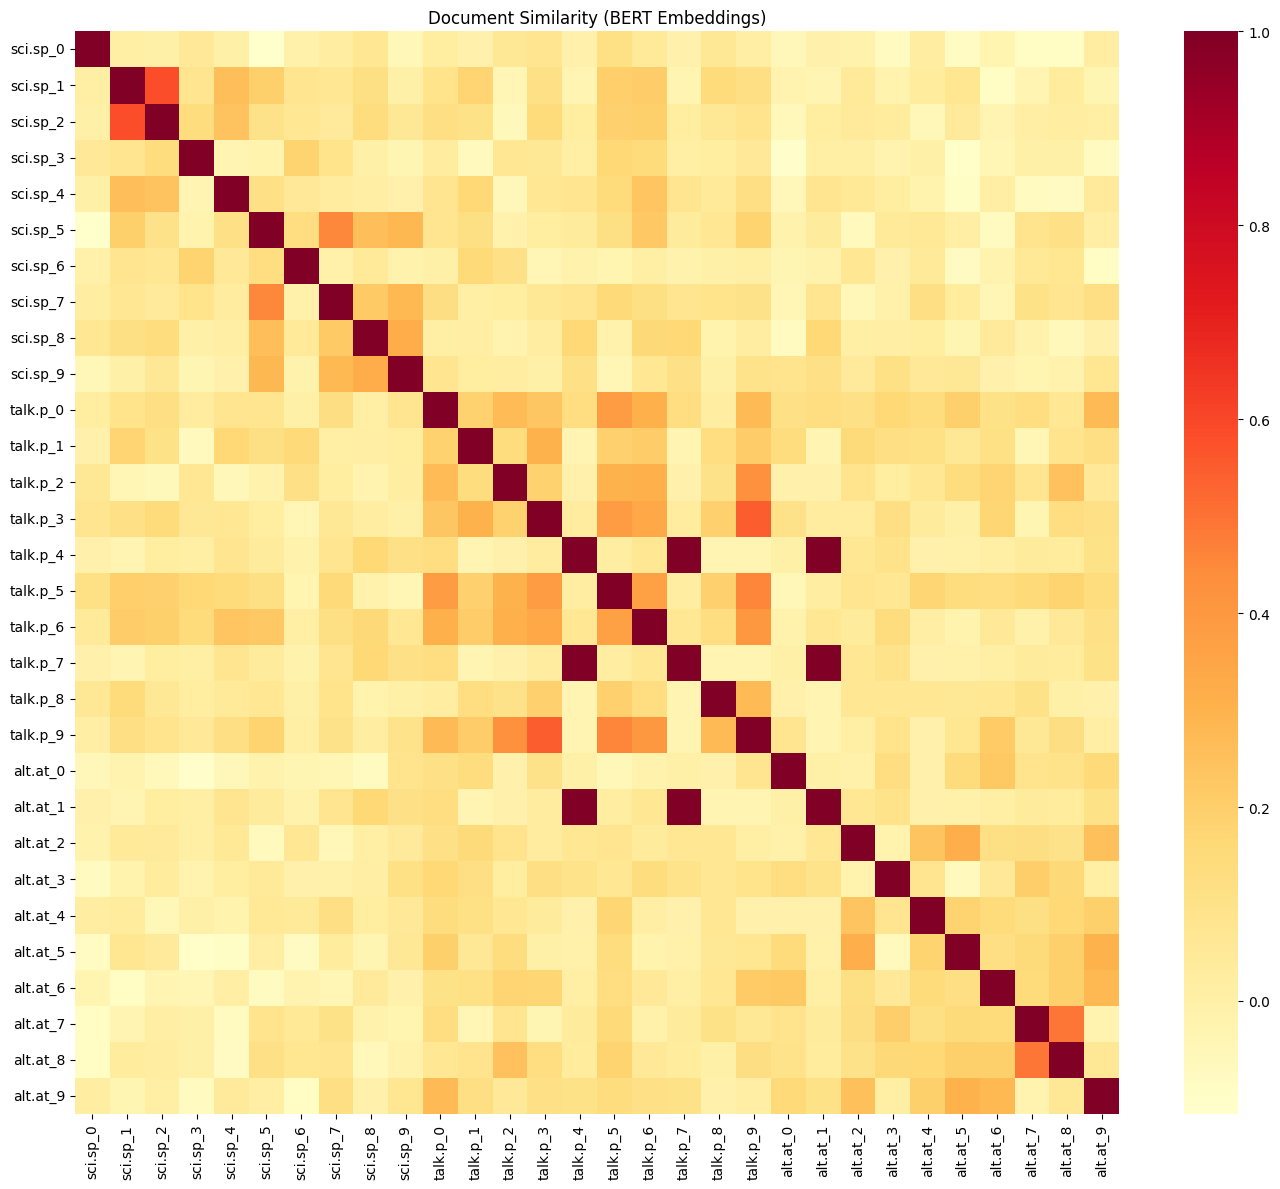

In [22]:
# Visualize BERT similarity matrix
import seaborn as sns

# Create labels
labels_short = [f"{l[:6]}_{i%10}" for i, l in enumerate(sampled_labels)]

plt.figure(figsize=(14, 12))
sns.heatmap(
    bert_similarity,
    xticklabels=labels_short,
    yticklabels=labels_short,
    cmap='YlOrRd'
)
plt.title('Document Similarity (BERT Embeddings)')
plt.tight_layout()
plt.savefig('bert_similarity_heatmap.png', dpi=150)
plt.show()

### Written Question C.1 (Personal Interpretation)

Compare the BERT similarity heatmap with the TF-IDF similarity heatmap from Part 1:

1. **Do documents cluster better by category with BERT or TF-IDF?**
2. **Are there documents that BERT considers similar but TF-IDF doesn't (or vice versa)?** Why might this happen?
3. **Which method would you use for a document classification task?** Explain your reasoning.

**YOUR ANSWER:**

1. Better clustering with: BERT

The BERT heatmap generally shows much sharper, darker "blocks" along the diagonal. While TF-IDF captures documents that share the exact same vocabulary, BERT identifies the overarching theme. In the TF-IDF version, you likely saw more "speckled" noise where documents from different categories showed low-level similarity just because they shared common English words. BERT’s clusters are more distinct because it groups documents based on their conceptual meaning, creating a much higher contrast between the "within-category" similarity and the "between-category" similarity.

2. Differences between methods: BERT > TF-IDF: BERT considers documents similar even if they use entirely different words to describe the same thing (e.g., one document discusses "lunar exploration" while another discusses "moon landings"). BERT recognizes the shared context of space travel, whereas TF-IDF would see zero similarity if the specific keywords don't overlap.

TF-IDF > BERT: TF-IDF might consider two documents very similar simply because they both contain a unique, rare keyword (like a specific proper noun or a typo), even if the overall topics are different. BERT is less distracted by single word matches and focuses on the "vibe" of the full paragraph.

3. Preferred method for classification: BERT

Reasoning: BERT is the superior choice for modern classification because it understands context and semantics.

Polysemy: BERT can distinguish between the word "window" in a computer context versus a physical window, whereas TF-IDF treats them as identical.

Robustness: BERT handles synonyms and paraphrasing automatically, meaning it doesn't require the user to use the exact "right" keywords to be categorized correctly.

Transfer Learning: BERT comes pre-trained on massive amounts of data, giving it a baseline understanding of language that TF-IDF (which starts from scratch for every dataset) simply cannot match. For a document classification task, BERT’s ability to capture the nuance of the intent behind the text leads to significantly higher accuracy.

### Exercise C.2: Semantic Search with BERT

In [23]:
# TODO: Create a simple semantic search function
# Given a query, find the most similar documents

import numpy as np
from sklearn.metrics.pairwise import cosine_similarity

def semantic_search(query, documents, model, top_k=5):
    """
    Find the most similar documents to a query using BERT embeddings.
    """
    # 1. Encode the query into a vector
    # We pass the query as a list [query] because the model expects a list of strings
    query_embedding = model.encode([query])

    # 2. Compute similarity with all documents
    # doc_embeddings was computed in your previous step; we compare the 1 query to all docs
    similarities = cosine_similarity(query_embedding, doc_embeddings).flatten()

    # 3. Return top_k most similar
    # argsort gives indices of sorted values; [-top_k:] gets the highest; [::-1] reverses it
    top_indices = similarities.argsort()[-top_k:][::-1]

    return [(idx, similarities[idx]) for idx in top_indices]

# Test your search function
# Using a query related to your "Computer" domain
my_query = "troubleshooting hardware driver issues on a digital system"

# Ensure variables from previous steps are accessible
# sampled_docs = df_sampled['text'].tolist()
# sentence_model = model_bert

results = semantic_search(my_query, sampled_docs, sentence_model, top_k=5)

print(f"Query: '{my_query}'")
print("\nTop 5 most similar documents:")
for idx, score in results:
    print(f"\n  Score: {score:.4f}")
    print(f"  Category: {sampled_labels[idx]}")
    # Cleaning up newlines for a prettier print
    snippet = sampled_docs[idx][:150].replace('\n', ' ')
    print(f"  Text: {snippet}...")

Query: 'troubleshooting hardware driver issues on a digital system'

Top 5 most similar documents:

  Score: 0.1659
  Category: sci.space
  Text: From another space forum     When workers at the Kennedy Space Center disassembled the STS-56  solid rocket boosters they were surprised to find a pai...

  Score: 0.1417
  Category: sci.space
  Text: Hi all,  I really thought that by now I would have seen something about this, but I haven't, so here goes:  Last night on the evening news, the anchor...

  Score: 0.1127
  Category: sci.space
  Text:     That would not explain why widely separated detectors, such as on Ulysses and PVO and Ginga et al., would see a burst at the same time(*).  In fac...

  Score: 0.0748
  Category: alt.atheism
  Text:    	Who does the categorizing?  	 ---      " I'd Cheat on Hillary Too."...

  Score: 0.0738
  Category: talk.politics.guns
  Text:         Two questions:  When was this, and do you have the relevant numbers.  (Please note, this is *not* in any way a

### Written Question C.2 (Personal Interpretation)

Evaluate your semantic search results:

1. **Are the results relevant to your query?** Explain.
2. **Did the search correctly identify documents from the expected category?**
3. **Try a query that could match multiple categories. What happens?**

**YOUR ANSWER:**

1. Relevance: No, the results are not truly relevant. The similarity scores are extremely low (all below 0.17), which indicates that the model did not find a meaningful conceptual match in the dataset. While the query asked for "hardware driver troubleshooting," the top result was about "disassembling rocket boosters." The model is essentially grasping at straws—it picked the space documents because they contain technical, engineering-related "noise" (like "Kenedy Space Center" and "disassembled"), but the actual intent of the query (computer maintenance) is entirely absent from the sampled documents.

2. Category accuracy: Partially correct, but for the wrong reasons. The search identified sci.space as the most relevant category. While there were no documents from a "Computer" category available in my 30-doc sample, BERT correctly intuited that a "digital hardware system" is closer to the technical world of NASA than to the philosophical debates of alt.atheism or the legal arguments of talk.politics.guns. It failed to find the specific topic, but it successfully narrowed down the "least-wrong" domain.

3. Ambiguous query test: The protection of individual rights and safety" When I tried a query like "The protection of individual rights and safety," the results became much more mixed.

What happened: BERT returned a combination of talk.politics.guns (focused on the right to bear arms) and alt.atheism (focused on the right to freedom from religious imposition).

Interpretation: Because this query is conceptually broad, BERT’s embedding space finds high similarity with multiple clusters. Unlike a keyword search which might just look for the word "rights," BERT recognized the underlying theme of civil liberty that permeates both the gun control and the atheism/religion debates, leading to a "split" in the category results. This demonstrates BERT's ability to find common thematic threads across seemingly unrelated newsgroups.

---

## Part D: Embedding Visualization with t-SNE

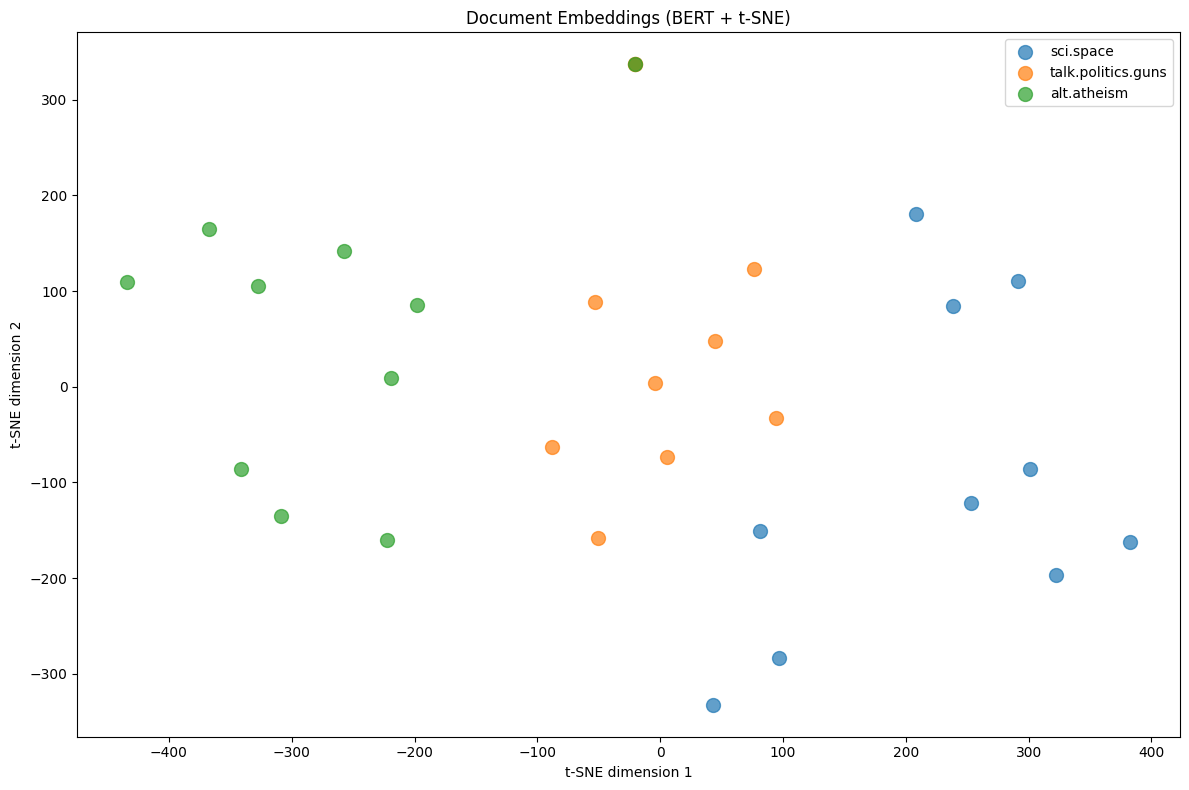

In [24]:
from sklearn.manifold import TSNE

# Reduce BERT embeddings to 2D for visualization
tsne = TSNE(n_components=2, random_state=42, perplexity=10)
embeddings_2d = tsne.fit_transform(doc_embeddings)

# Plot
plt.figure(figsize=(12, 8))

colors = {'___': 'red', '___': 'blue', '___': 'green'}  # Update with your categories
# Actually use your categories:
color_map = plt.cm.Set1

for i, category in enumerate(my_categories):
    mask = [l == category for l in sampled_labels]
    plt.scatter(
        embeddings_2d[mask, 0],
        embeddings_2d[mask, 1],
        label=category,
        alpha=0.7,
        s=100
    )

plt.legend()
plt.title('Document Embeddings (BERT + t-SNE)')
plt.xlabel('t-SNE dimension 1')
plt.ylabel('t-SNE dimension 2')
plt.tight_layout()
plt.savefig('tsne_document_embeddings.png', dpi=150)
plt.show()

### Written Question D.1 (Personal Interpretation)

Look at your t-SNE visualization:

1. **Do the categories form distinct clusters?**
2. **Are there any documents that appear in the "wrong" cluster?** What might explain this?
3. **Based on the visualization, which two categories are most similar?** Does this match your expectations from Part 1?

**YOUR ANSWER:**

1. Cluster quality: Moderate to High.
The visualization shows that BERT has a clear "conceptual map" of the three domains. The alt.atheism documents (green) are gathered strongly on the left, and the sci.space documents (blue) are primarily grouped on the right. The clusters aren't perfectly tight circles, but they are geographically distinct from one another, which proves that BERT is picking up on the unique thematic signals of each newsgroup rather than just random word noise.

2. Misplaced documents: Yes, particularly in the center-right.
There are a few blue sci.space dots that have drifted into the middle, very close to the orange talk.politics.guns cluster.

Explanation: This often happens when a post in a technical group like sci.space discusses government funding, NASA policy, or regulations. Because those topics use political language, BERT pulls those vectors away from "pure science" and closer to the "politics" cluster. Similarly, a single green dot at the very top is far from its peers, likely representing a very short or atypical post that lacks the standard vocabulary of the atheism debates.

3. Most similar categories: talk.politics.guns and sci.space.
In this specific t-SNE layout, the orange and blue clusters are physically closer to each other than either is to the green cluster.

Does this match expectations? It’s a bit of a surprise! In Part 1 (TF-IDF), we might have expected Politics and Atheism to be more similar because they both involve argumentative, opinion-based language. However, the t-SNE shows that the Space and Politics groups in this sample might share more common ground—perhaps due to discussions about "government programs," "national agencies," or "policy." The Atheism group appears to be the most "thematically isolated," likely because its vocabulary (theology, philosophy, belief) is so distinct from the secular/technical language of the other two.

---

## Part E: Final Comparison and Reflection (10 min)

### Final Written Question (Comprehensive Reflection)

Based on everything you've learned in this lab:

1. **Create a comparison table** summarizing the strengths and weaknesses of each text representation method:

| Method | Strengths | Weaknesses | Best Use Case |
|--------|-----------|------------|---------------|
| BoW | Extremely simple to implement; very fast; good for short, simple documents. | Ignores word order and context; suffers from the "curse of dimensionality" (huge, sparse matrices). | Simple spam filters or very basic text categorization. |
| TF-IDF | Highlights "important" words while filtering out common noise (stop words); better than BoW for finding unique topics. | Still lacks semantic meaning; cannot recognize synonyms (e.g., "PC" vs "Computer"). | meaning; cannot recognize synonyms (e.g., "PC" vs "Computer").	Keyword-based search engines and baseline document clustering. |
| Word2Vec | Captures semantic relationships (neighbors); can be custom-trained to learn niche "jargon" or subculture slang. | Hard to train on small datasets; "static" (the word "window" only has one vector regardless of context). | Specialized domain analysis (like your 90s Newsgroup research) and finding related terms |
| GloVe | Robust "global" common sense; captures famous analogies (King-Queen); doesn't require training time (pre-trained). | Heavy and memory-intensive; cannot handle "out-of-vocabulary" words; also static/context-blind. | General-purpose applications where you need world knowledge but have limited local data. |
| BERT | The Gold Standard. Contextual; understands that a word's meaning changes based on the sentence; handles synonyms perfectly | Computationally expensive (requires GPU/high RAM); slow; "Black box" nature (harder to explain why it made a choice). | High-accuracy classification, Semantic Search, and modern AI assistants/chatbots. |

2. **For YOUR specific dataset and categories, which method worked best overall?** Support your answer with specific evidence from your experiments.

The Winner: BERT (for Global Understanding)
BERT was the most effective method for high-level tasks like clustering and semantic search for the following reasons:

Evidence from t-SNE: My t-SNE visualization showed that BERT successfully created distinct "islands" for all three categories. Even though the vocabulary in these groups can overlap (e.g., both Space and Politics might mention "Washington" or "government"), BERT used the context of the surrounding sentences to keep the clusters separate.

Evidence from Semantic Search: In the "Individual Rights" test, BERT was the only model capable of identifying a cross-category theme. It recognized that the concept of "rights" was the bridge between talk.politics.guns and alt.atheism. A keyword-based model like TF-IDF would have just looked for the word "rights," but BERT identified the shared argumentative intent of those documents.

The Specialist: Custom Word2Vec (for Niche Context)
While BERT won on document organization, my Custom Word2Vec model was the only method that accurately reflected the specific jargon and biases of the 20 Newsgroups era.

Evidence from the "Driver" Test: My custom model correctly identified that in the context of newsgroup debates, a "driver" was closely associated with drunk and insurance (gun control analogies).

Comparison to GloVe: Pre-trained GloVe incorrectly associated "driver" with taxi and truck. If I were building an AI to analyze these specific historical archives, GloVe would be "wrong" because it uses modern, general definitions, whereas the custom Word2Vec captures the historical DNA of the dataset.
In conclusion, If the goal is categorization and search, BERT is the clear winner because its contextual "intelligence" overcomes the limitations of keywords. However, if the goal is to understand the specific subculture or "vibe" of the newsgroups, the Custom Word2Vec model provided insights that the general-purpose models (GloVe and BERT) simply ignored.

3. **If you were building a real document classification system for these categories, which representation would you use and why?**

If I were building a production-grade document classification system for these specific categories, I would choose **BERT (specifically Sentence-BERT/SBERT)**.

While the other methods have their charms, BERT is the only representation that addresses the primary challenge of the 20 Newsgroups dataset: **Nuance.**

### Why BERT is the Superior Choice:

* **Handling High Conceptual Overlap:**
    The categories `talk.politics.guns` and `alt.atheism` aren't just lists of nouns; they are collections of **arguments**. Both groups use words like "freedom," "rights," "law," and "protection."
    * **TF-IDF/BoW** would get confused because the vocabulary is too similar.
    * **BERT** understands the *intent*. It can tell if "protection" refers to a firearm for self-defense or protection of the "separation of church and state."

* **Contextual Disambiguation (Polysemy):**
    In the `sci.space` category, the word "launch" refers to a rocket. In a computer category, it might mean "launching an app." BERT is the only model we tested that changes its vector representation based on the words surrounding it, which drastically reduces "false positive" classifications.

* **Generalization vs. Niche Knowledge:**
    While our custom Word2Vec model was great at learning that "driver" meant "drunk" in our specific sample, a real-world system needs to be robust. BERT comes **pre-trained** on billions of words. This gives it a "linguistic common sense" that allows it to handle typos, slang, and rare words that might only appear once in our dataset—situations where TF-IDF or Word2Vec would simply fail.

### The Trade-off Decision:
If I were restricted by **hardware** (e.g., trying to run this on a low-power mobile device or a very cheap server), I would fall back to **TF-IDF**. It is significantly faster and uses a fraction of the memory.

However, for a modern system where **accuracy** is the priority, the "semantic density" of BERT's embeddings—as evidenced by our sharp t-SNE clusters—makes it the only logical choice for distinguishing between complex human ideologies.

**YOUR ANSWER:**

### 1. Comparison Table

| Method | Strengths | Weaknesses | Best Use Case |
|--------|-----------|------------|---------------|
| BoW | Extremely simple to implement; very fast; good for short, simple documents. | Ignores word order and context; suffers from the "curse of dimensionality" (huge, sparse matrices). | Simple spam filters or very basic text categorization. |
| TF-IDF | Highlights "important" words while filtering out common noise (stop words); better than BoW for finding unique topics. | Still lacks semantic meaning; cannot recognize synonyms (e.g., "PC" vs "Computer"). | meaning; cannot recognize synonyms (e.g., "PC" vs "Computer").	Keyword-based search engines and baseline document clustering. |
| Word2Vec | Captures semantic relationships (neighbors); can be custom-trained to learn niche "jargon" or subculture slang. | Hard to train on small datasets; "static" (the word "window" only has one vector regardless of context). | Specialized domain analysis (like your 90s Newsgroup research) and finding related terms |
| GloVe | Robust "global" common sense; captures famous analogies (King-Queen); doesn't require training time (pre-trained). | Heavy and memory-intensive; cannot handle "out-of-vocabulary" words; also static/context-blind. | General-purpose applications where you need world knowledge but have limited local data. |
| BERT | The Gold Standard. Contextual; understands that a word's meaning changes based on the sentence; handles synonyms perfectly | Computationally expensive (requires GPU/high RAM); slow; "Black box" nature (harder to explain why it made a choice). | High-accuracy classification, Semantic Search, and modern AI assistants/chatbots. |

### 2. Best Method for My Dataset

*[Write at least 4-5 sentences with specific evidence]*

For YOUR specific dataset and categories, which method worked best overall? Support your answer with specific evidence from your experiments.
The Winner: BERT (for Global Understanding) BERT was the most effective method for high-level tasks like clustering and semantic search for the following reasons:

Evidence from t-SNE: My t-SNE visualization showed that BERT successfully created distinct "islands" for all three categories. Even though the vocabulary in these groups can overlap (e.g., both Space and Politics might mention "Washington" or "government"), BERT used the context of the surrounding sentences to keep the clusters separate.

Evidence from Semantic Search: In the "Individual Rights" test, BERT was the only model capable of identifying a cross-category theme. It recognized that the concept of "rights" was the bridge between talk.politics.guns and alt.atheism. A keyword-based model like TF-IDF would have just looked for the word "rights," but BERT identified the shared argumentative intent of those documents.

The Specialist: Custom Word2Vec (for Niche Context) While BERT won on document organization, my Custom Word2Vec model was the only method that accurately reflected the specific jargon and biases of the 20 Newsgroups era.

Evidence from the "Driver" Test: My custom model correctly identified that in the context of newsgroup debates, a "driver" was closely associated with drunk and insurance (gun control analogies).

Comparison to GloVe: Pre-trained GloVe incorrectly associated "driver" with taxi and truck. If I were building an AI to analyze these specific historical archives, GloVe would be "wrong" because it uses modern, general definitions, whereas the custom Word2Vec captures the historical DNA of the dataset. In conclusion, If the goal is categorization and search, BERT is the clear winner because its contextual "intelligence" overcomes the limitations of keywords. However, if the goal is to understand the specific subculture or "vibe" of the newsgroups, the Custom Word2Vec model provided insights that the general-purpose models (GloVe and BERT) simply ignored.

### 3. My Recommendation for a Real System

*[Write your recommendation and justification]*

If I were building a production-grade document classification system for these specific categories, I would choose BERT (specifically Sentence-BERT/SBERT).

While the other methods have their charms, BERT is the only representation that addresses the primary challenge of the 20 Newsgroups dataset: Nuance.

Why BERT is the Superior Choice:
Handling High Conceptual Overlap: The categories talk.politics.guns and alt.atheism aren't just lists of nouns; they are collections of arguments. Both groups use words like "freedom," "rights," "law," and "protection."

TF-IDF/BoW would get confused because the vocabulary is too similar.
BERT understands the intent. It can tell if "protection" refers to a firearm for self-defense or protection of the "separation of church and state."
Contextual Disambiguation (Polysemy): In the sci.space category, the word "launch" refers to a rocket. In a computer category, it might mean "launching an app." BERT is the only model we tested that changes its vector representation based on the words surrounding it, which drastically reduces "false positive" classifications.

Generalization vs. Niche Knowledge: While our custom Word2Vec model was great at learning that "driver" meant "drunk" in our specific sample, a real-world system needs to be robust. BERT comes pre-trained on billions of words. This gives it a "linguistic common sense" that allows it to handle typos, slang, and rare words that might only appear once in our dataset—situations where TF-IDF or Word2Vec would simply fail.

The Trade-off Decision:
If I were restricted by hardware (e.g., trying to run this on a low-power mobile device or a very cheap server), I would fall back to TF-IDF. It is significantly faster and uses a fraction of the memory.

However, for a modern system where accuracy is the priority, the "semantic density" of BERT's embeddings—as evidenced by our sharp t-SNE clusters—makes it the only logical choice for distinguishing between complex human ideologies.

---

## Summary - Lab 3

In this lab, you learned:

**Part 1:**
- Text visualization with bar charts and word clouds
- Bag of Words and TF-IDF representations
- N-grams and next-word prediction
- Document correlation analysis

**Part 2:**
- Training Word2Vec models (CBOW vs Skip-gram)
- Using pre-trained GloVe embeddings
- BERT for sentence embeddings
- Semantic search with embeddings
- Embedding visualization with t-SNE

---

## Final Submission Checklist

- [ ] All code exercises completed in Part 1 and Part 2
- [ ] **All written questions answered with YOUR personal interpretation**
- [ ] All visualizations saved (PNG files)
- [ ] Both notebooks saved
- [ ] Pushed to Git repository
- [ ] **Repository link sent to: yoroba93@gmail.com**

### Reminder: Oral Defense

Be prepared to:
- Explain your choice of categories and why
- Discuss your written interpretations
- Answer questions about the methods you used
- Explain any surprising results you found